<div style="display: flex; align-items: center;">
    <img src="https://github.com/nagelt/Teaching_Scripts/raw/9d9e29ecca4b04eaf7397938eacbf116d37ddc93/Images/TUBAF_Logo_blau.png"
         width="500" height="auto" style="margin-right: 100px;" />
    <div>
        <p><strong>Prof. Dr. Thomas Nagel</strong></p>
        <p>
            Chair of Soil Mechanics and Foundation Engineering<br>
            Geotechnical Institute<br>
            Technische Universität Bergakademie Freiberg.
        </p>
        <p>
            <a href="https://tu-freiberg.de/en/soilmechanics">
                https://tu-freiberg.de/en/soilmechanics
            </a>
        </p>
    </div>
</div>

<div style="display: flex; align-items: center;">
    <p style="margin-top: 1em;">
        To activate the <strong>interactive features</strong> when in nbviewer mode, click on &quot;Execute on Binder&quot;
        <img src="https://mybinder.org/static/favicon.ico"
             alt="Binder"
             style="height: 1.1em; vertical-align: middle; margin: 0 6px;">
        on the top right. Then, click on Run → Run All Cells.
    </p>
</div>


# EQU-Nachweis gegen Kippen und Bettungsmodulverfahren mit zugfreien Federn

## Grenzzustand des Verlusts der Lagesicherheit (EQU) für starre Streifenfundamente

In [12]:
import numpy as np #numerical methods
import matplotlib.pyplot as plt #plotting

#Some plot settings
import plot_functions.plot_settings
%run plot_functions/Kippnachweis_plots.ipynb

## 1. Rahmen: Kippen als Grenzzustand des Verlusts der Lagesicherheit (EQU)

Wir betrachten einen ebenen Querschnitt durch ein **starres Streifenfundament** der Breite $a$. Alle resultierenden Kraft- und Momentengrößen beziehen sich auf eine Längeneinheit des Fundaments senkrecht zur Zeichenebene: $V$ ist die Vertikallinienlast in $\mathrm{kN/m}$ und $M$ das zugehörige Linienmoment in $\mathrm{kNm/m}$. Eine solche Momentenbeanspruchung entsteht z.B. aus einer Horizontallinienlast in einer bestimmten Höhe über der Sohlfuge. Die Exzentrizität der vertikalen Resultierenden lautet:

$$
    e_x = \frac{M}{V}
$$

Wird $e_x$ immer größer, wandert der Angriffspunkt der Resultierenden in Richtung einer Fundamentkante. Der **EQU-Grenzzustand "Kippen"** ist erreicht, wenn die Resultierende die Kante der Sohlfläche erreicht ($|e_x| = a/2$): Für jede größere Exzentrizität lässt sich keine Sohldruckverteilung mehr finden, die ausschließlich aus Druckspannungen besteht und gleichzeitig Kräfte- und Momentengleichgewicht erfüllt -- das Fundament verliert die Gleichgewichtslage und kippt um die betreffende Kante. Dies ist von der aus [sohldruck.ipynb](sohldruck.ipynb) bekannten **klaffenden Fuge** zu unterscheiden: Eine klaffende Fuge beginnt bereits bei $|e_x|>a/6$, ist für sich allein aber noch kein Kippen. Sie reduziert jedoch die wirksame Kontaktfläche und ist deshalb nicht nur für Gebrauchstauglichkeits-, sondern auch für Tragfähigkeitsnachweise relevant.

Wir fassen die dort hergeleiteten Ergebnisse für den 1D-Fall (Streifenfundament, $e_y \equiv 0$) zusammen. Mit $\xi = x/a \in [-1/2,1/2]$ und der mittleren Sohldruckspannung $\bar\sigma_0 = V/a$ gilt für die **volle Aufstandsfläche** ($|e_x/a| \leq 1/6$, innerhalb der 1. Kernweite):

$$
    \sigma_0(\xi) = \bar\sigma_0 \left(1 + 12 \frac{e_x}{a}\xi\right)
$$

Wird die 1. Kernweite überschritten ($|e_x/a| > 1/6$), stellt sich eine **klaffende Fuge** ein. Die Kontaktzone reduziert sich auf ein Dreieck der Breite $L_c$ am belasteten Rand:

$$
    \frac{L_c}{a} = 3\left(\frac12 - \left|\frac{e_x}{a}\right|\right), \qquad \sigma_\text{E} = \frac{2V}{L_c}
$$

wobei $\sigma_\text{E}$ die Eckspannung am belasteten Rand ist (aus dem Gleichgewicht der Dreieckslast mit $V$). Für $|e_x/a| = 1/3$ (2. Kernweite) reicht die klaffende Fuge gerade bis zum Schwerpunkt ($L_c = a/2$); für $|e_x/a| \to 1/2$ schrumpft die Kontaktbreite gegen null, während $\sigma_\text{E} \to \infty$ strebt.

**Das ist genau der EQU-Grenzzustand:** Die Bedingung $L_c \geq 0$, äquivalent zu

$$
    \boxed{|e_x| \leq \frac{a}{2}}
$$

ist die geometrische Bedingung für die Standsicherheit gegen Kippen bei rein vertikaler resultierender Belastung. Sie ist äquivalent zur klassischen Formulierung über das Momentengleichgewicht um die Kippkante ($\sum M_\text{stabilisierend} \geq \sum M_\text{kippend}$).

**Anmerkung:** Diese rein geometrisch-statische Betrachtung ist eine notwendige, aber nicht hinreichende Bedingung. Mit abnehmender Kontaktbreite steigt $\sigma_\text{E}$ stark an; daher kann der separat zu führende Grundbruchnachweis (GEO, allgemeine Bruchmechanismen vgl. [Grundbruch.ipynb](Grundbruch.ipynb)) bereits bei kleinerer Exzentrizität maßgebend werden. Bei zusätzlichen Horizontallasten ist außerdem der Nachweis gegen Gleiten zu führen. Hier werden -- wie bei den Kernweiten in [sohldruck.ipynb](sohldruck.ipynb) -- zunächst charakteristische Größen betrachtet. Ein formaler Nachweis ist mit den nach dem jeweils anzuwendenden Normenstand gebildeten Bemessungswerten und Einwirkungskombinationen zu führen; insbesondere dürfen günstige und ungünstige Einwirkungsanteile nicht erst nach ihrer Summation pauschal faktorisiert werden.

Zunächst stellen wir den Grenzzustand **vorab** dar: die Kontaktbreite $L_c/a$ als Funktion der Exzentrizität, mit den bekannten Kernweiten und der neuen Kippgrenze.

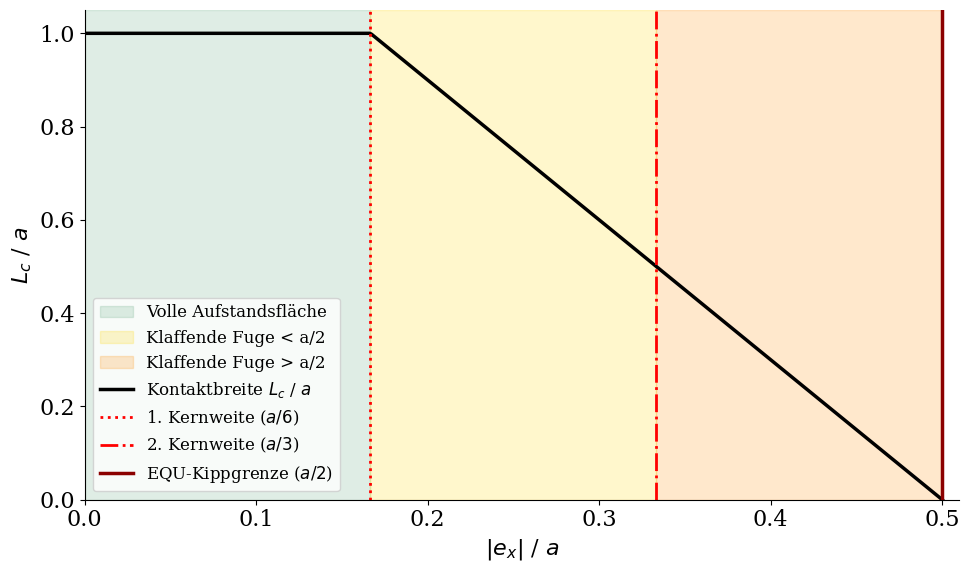

In [13]:
plot_kippgrenze_precompute()

In der folgenden interaktiven Darstellung lassen sich die mittlere Sohldruckspannung $V/a$ und die bezogene Exzentrizität $e_x/a$ frei einstellen (auch über die Kippgrenze hinaus). Dabei ist $V$ weiterhin eine Vertikallinienlast in $\mathrm{kN/m}$. Links ist das Fundament mit der Sohldruckverteilung skizziert (grün: Kontakt, rot schraffiert: klaffende Fuge bzw. vollständiger Verlust des Kontakts), inklusive der 1./2. Kernweite und der Kippgrenze auf der Basislinie; rechts die zugehörige Sohldruckverteilung $\sigma_0(x)$.

In [14]:
interactive_kippnachweis()

interactive(children=(IntSlider(value=100, description='$V/a$ / kPa', max=300, min=10, step=10, style=SliderSt…

## 2. Federmodell: starres Fundament auf zugfreien Einzelfedern

Bislang haben wir die Sohldruckverteilung aus der Annahme einer ebenen (linearen) Verteilung plus Gleichgewichtsbedingungen hergeleitet ("Spannungstrapezverfahren"). Wir zeigen nun, dass sich dieselbe Lösung ergibt, wenn man das Fundament stattdessen auf $N$ unabhängigen, ausschließlich **druckfesten** (zugfreien) **Bettungsfedern** lagert -- ein diskretes Winkler-Modell.

Wir diskretisieren die Fundamentbreite in $N$ Teilstreifen mit den Mittelpunkten $\xi_i = -\tfrac12 + \left(i+\tfrac12\right)\Delta\xi$, $\Delta\xi = 1/N$. Bei der dimensionsbehafteten Teilbreite $\Delta x=a/N$ besitzt die zugehörige Einzelfeder je Längeneinheit des Streifenfundaments die Steifigkeit $K'_i=k_\text{s}\Delta x$. Ihre Reaktionslinienlast ist $q_i=K'_i s_i$; bezogen auf die Teilbreite ergibt sich die Sohldruckspannung $\sigma_i=q_i/\Delta x=k_\text{s}s_i$. Bleibt das Fundament -- wie bisher -- **starr**, dann ist die Setzungslinie linear:

$$
    s(\xi) = s_0 + \varphi\,\xi \qquad \Rightarrow \qquad \sigma_i = k_\text{s}\big(s_0 + \varphi\,\xi_i\big) \quad \text{sofern } s_i \geq 0
$$

Federn, für die sich rechnerisch $\sigma_i < 0$ (Zug) ergäbe, können keine Reaktionslinienlast übertragen (**Kontaktbedingung**, $\sigma_i = 0$ statt Zug) und werden aus dem aktiven System entfernt. Für die verbleibenden aktiven Federn (Indexmenge $\mathcal{A}$) müssen Linienkraft- und Linienmomentengleichgewicht in diskreter Form erfüllt sein (Summen statt Integrale, vgl. die kontinuierliche Herleitung in [sohldruck.ipynb](sohldruck.ipynb)):

$$
    \sum_{i \in \mathcal{A}} \sigma_i\,\Delta x = V, \qquad \sum_{i \in \mathcal{A}} \sigma_i\,x_i\,\Delta x = M = V e_x.
$$

Mit $x_i=a\xi_i$ und $\Delta x=a\Delta\xi$ folgt daraus die im Rechenmodell verwendete normierte Form:

$$
    \sum_{i \in \mathcal{A}} \sigma_i\,\Delta\xi = \bar\sigma_0, \qquad \sum_{i \in \mathcal{A}} \sigma_i\,\xi_i\,\Delta\xi = \bar\sigma_0\,\frac{e_x}{a}
$$

Da beide Gleichungen in $s_0$ und $\varphi$ linear sind, lässt sich pro Iterationsschritt ein $2\times2$-System lösen. Die Lösung erfolgt **iterativ** (Active-Set-Verfahren):

1. Starte mit allen $N$ Federn aktiv.
2. Löse das $2\times2$-Gleichgewichtssystem für die Koeffizienten der (linearen) Sohldrucklinie.
3. Werden für Federn negative Spannungen (Zug) berechnet, deaktiviere diese Federn.
4. Wiederhole 2.-3., bis sich die aktive Menge nicht mehr ändert.

Bemerkenswert: Der einheitliche Bettungsmodul $k_\text{s}$ **kürzt sich heraus** -- bei gleichförmiger Bettung eines starren Körpers hängt die Kontaktspannungsverteilung nur von $V$, $e_x$ und der Geometrie ab, nicht von der Steifigkeit der Federn. Das Ergebnis konvergiert mit wachsendem $N$ gegen die kontinuierliche Lösung aus Abschnitt 1. Bei endlichem $N$ liegt die äußerste Feder im Mittelpunkt ihrer Teilfläche, sodass die diskrete maximal darstellbare Exzentrizität $|e_x/a|<1/2-1/(2N)$ beträgt. Das numerische Versagen bei weniger als zwei aktiven Federn nähert sich daher erst für $N\to\infty$ der geometrischen Kippgrenze $1/2$.

Mit dem Regler $N$ lässt sich die Diskretisierung verändern und die Konvergenz der diskreten Lösung (grüne Balken) gegen die kontinuierliche Lösung (schwarze Kurve) beobachten. Abgehobene (zugfreie) Federn werden gestrichelt/grau dargestellt, aktive (gedrückte) Federn grün -- die Strichstärke skaliert mit der je Längeneinheit übertragenen Reaktionslinienlast.

In [ ]:
interactive_federmodell()

interactive(children=(IntSlider(value=100, description='$V/a$ / kPa', max=300, min=10, step=10, style=SliderSt…

## Fazit

Beide Modelle -- die starre Spannungstrapez-/Dreiecklösung und das diskrete Federmodell mit Zugausschluss -- liefern dieselbe physikalische Grenze: Die Kontaktfläche schrumpft mit wachsender Exzentrizität monoton, bis sie bei $|e_x| = a/2$ verschwindet. Dort ist der EQU-Grenzzustand "Verlust der Lagesicherheit durch Kippen" erreicht. Das Federmodell macht dabei anschaulich sichtbar, *warum* Zugspannungen in der Sohlfuge ausgeschlossen werden müssen: einzelne Federn heben schlicht ab, sobald ihre rechnerische Beanspruchung ins Negative liefe.

Für die Bemessungspraxis ist zusätzlich zu beachten:
- Der formale EQU-Nachweis ist mit den Bemessungswerten der einzelnen günstigen und ungünstigen Einwirkungen nach dem anzuwendenden Normenstand zu bilden. Nur wenn diese Einwirkungsanteile bereits korrekt kombiniert wurden, darf die resultierende Bemessungsexzentrizität $e_{x,d}=M_d/V_d$ unmittelbar mit $a/2$ verglichen werden.
- Grundbruch und Gleiten sind eigenständige GEO-Nachweise. Sie können infolge der abnehmenden Kontaktfläche beziehungsweise zusätzlicher Horizontallasten bereits vor der geometrischen Kippgrenze maßgebend werden.

## 3. Turmbeispiel: Kippstabilität in Abhängigkeit von Neigung und Bettung

Die Eigenschaften des Bodens können die Kippstabilität beeinflussen, auch wenn sie sich im obigen Beispiel herausgekürzt haben. Wir betrachten dazu nun einen konkreten ebenen Fall: einen **starren Turm- beziehungsweise Wandstreifen** auf einem Streifenfundament. Der Querschnitt besitzt die Breite $a$ (= Breite der Sohlfuge), die Höhe $H$ und eine gleichförmige Wichte $\gamma=25\,\mathrm{kN/m^3}$. Die Schwerpunktlage entlang der Turmachse, gemessen vom Mittelpunkt der Sohlfuge, wird mit $z_\text{G0}$ bezeichnet; hier gilt $z_\text{G0}=H/2$. Sie ist keine globale Vertikalkoordinate. Alle resultierenden Größen gelten weiterhin je Längeneinheit senkrecht zur Zeichenebene. Damit ist das Eigengewicht die Vertikallinienlast $V=\gamma aH$ in $\mathrm{kN/m}$, und alle dargestellten Momente haben die Einheit $\mathrm{kNm/m}$. Anstatt die Exzentrizität $e_x$ direkt vorzugeben, fragen wir: **Ab welcher Neigung $\theta$ (Kippwinkel des Turm- beziehungsweise Wandstreifens aus der Vertikalen) geht die Standsicherheit verloren** -- getrennt für starren Baugrund und für das Federmodell mit zugfreien Federn aus Abschnitt 2?

**Kinematik:** Neigt sich der (als starr angenommene) Turm um den Winkel $\theta$, so beträgt der globale horizontale Abstand zwischen Schwerpunkt und Sohlflächenmittelpunkt

$$
    d(\theta) = z_\text{G0}\sin\theta.
$$

Dieser Abstand ist der Hebelarm des Eigengewichts für das Moment um den Sohlflächenmittelpunkt, also $M_\text{dest}=Vd$. Er darf nicht mit der in den Abschnitten 1 und 2 entlang der Sohlfläche gemessenen Exzentrizität verwechselt werden. Eine vertikale Resultierende, die im lokalen (ebenfalls gedrehten) Sohlkoordinatensystem bei $x_\text{R}$ angreift, besitzt den globalen Hebelarm $x_\text{R}\cos\theta$. Aus dem Momentengleichgewicht folgt daher

$$
    x_\text{R}(\theta)\cos\theta=z_\text{G0}\sin\theta
    \qquad\Rightarrow\qquad
    \boxed{x_\text{R}(\theta)=z_\text{G0}\tan\theta}.
$$

Damit lässt sich die geometrische Bedingung aus Abschnitt 1 konsistent auf den geneigten Turm übertragen.

### Starrer Baugrund: die klassische Kipp-("Wackelstein"-)Bedingung

Auf starrem Baugrund kann eine Neigung $\theta \ne 0$ nur dadurch entstehen, dass der Turm um eine seiner Sohlkanten **rotiert** (zwei starre Körper berühren sich nur entlang einer Linie). Solange die Schwerpunktprojektion noch innerhalb der Sohlfläche liegt, erzeugt die Schwerkraft ein **rückstellendes** Moment um die momentane Drehkante; sobald sie die Kante überschreitet, wird dieses Moment **kippend**. Die Grenze liegt dort, wo der Schwerpunkt exakt über der Kante steht:

$$
    \boxed{\theta_{\text{krit,starr}} = \arctan\left(\frac{a}{2 z_\text{G0}}\right)}
$$

Dies ist die klassische Standsicherheitsbedingung starrer Körper gegen Kippen (vgl. das "Rocking-Block"-Modell nach Housner) -- sie hängt **nicht** von der Masse/dem Gewicht des Turms ab (rein geometrisch), sondern nur vom Seitenverhältnis $a/H$.

**Energetische Deutung der starren Kippgrenze:** Bei einer Rotation um die belastete Sohlkante lautet die globale Vertikalkoordinate des Schwerpunkts

$$
    z_\mathrm{G}(\theta)=z_\mathrm{G0}\cos\theta+\frac{a}{2}\sin\theta.
$$

Sie steigt aus der aufrechten Lage zunächst an. Aus $\mathrm{d}z_\mathrm{G}/\mathrm{d}\theta=0$ folgt $\tan\theta=a/(2z_\mathrm{G0})$: Genau an der geometrischen Kippgrenze erreicht der Schwerpunkt seine größte Höhe und damit das Eigengewichtspotential $V[z_\mathrm{G}(\theta)-z_\mathrm{G}(0)]$ sein Maximum. Danach sinkt der Schwerpunkt; die Schwerkraft treibt das weitere Kippen an.

Eine nachgiebige Bettung kann einsinken und vermindert dadurch die zur Rotation erforderliche Kantenhebung. Die geometrische Höhenbarriere wird kleiner; die tatsächliche instabile Schwelle kann deshalb gegenüber $\theta_{\mathrm{krit,starr}}$ zu kleineren Winkeln verschoben sein. Der gestrichelte Grenzfall in der Grafik zeigt die Schwerpunktbewegung ohne Anhebung der oberen Sohlkante: Gegenüber der starren Rotation um die belastete Kante wird der gesamte Körper um $a\sin\theta$ abgesenkt. Er ist keine eigene Bettungslösung. Für eine endliche Bettungssteifigkeit müssen zusätzlich die gespeicherte Federenergie und das Vertikalgleichgewicht berücksichtigt werden; dies geschieht im folgenden Abschnitt mit dem reduzierten Gesamtpotential.

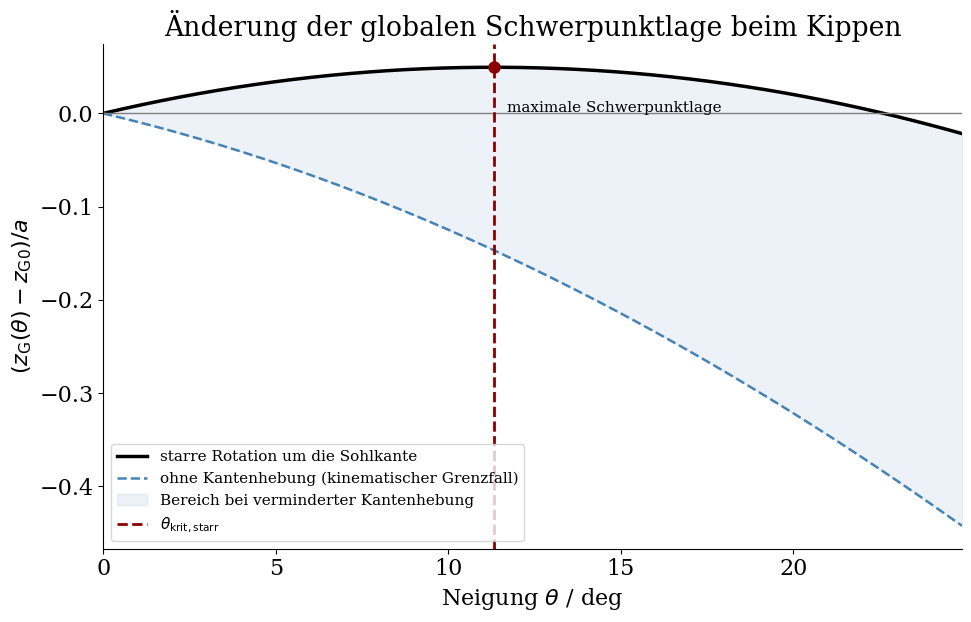

In [16]:
plot_schwerpunktlage()

### Federmodell: Stabilität statt reiner Gleichgewichtsfrage

Auf dem Federbett kann für jeden kinematisch vorgegebenen Winkel $\theta$ zunächst eine Spannungsverteilung bestimmt werden, die das **Vertikalgleichgewicht** $\int\sigma\,\mathrm{d}x=V$ erfüllt. Das ist noch kein vollständiger Gleichgewichtszustand: Zusätzlich muss das Momentenresiduum

$$
    G(\theta)=M_\text{found}(\theta)-M_\text{dest}(\theta)
$$

verschwinden. Für eine kleine Störung der aufrechten Lage wächst das destabilisierende Moment um

$$
    \mathrm{d}M_\text{dest} = \frac{\mathrm{d}}{\mathrm{d}\theta}\left[V z_\text{G0}\sin\theta\right] \mathrm{d}\theta \approx V z_\text{G0}\,\mathrm{d}\theta
$$

während die Bettung ein zusätzliches rückstellendes Moment $\mathrm{d}M_\text{found} = k_\varphi(\theta)\,\mathrm{d}\theta$ mobilisiert. Dabei ist $k_\varphi(\theta)=\mathrm{d}M_\text{found}/\mathrm{d}\theta$ die Tangentensteifigkeit entlang der durch das Vertikalgleichgewicht bestimmten Konfigurationen. Solange die Bettung linear-elastisch ist und alle Federn im Kontakt bleiben, gilt am Ausgangszustand

$$
    k_\varphi(0) = k_\text{s}\int_{-a/2}^{a/2}x^2\,\mathrm{d}x = \frac{k_\text{s}\,a^3}{12}
$$

**Stabilitätskriterium bei $\theta=0$:** Der Turm ist infinitesimal stabil, wenn die zweite Variation positiv ist, also die anfängliche Bettungssteifigkeit das geometrische Kippglied übersteigt:

$$
    \boxed{k_\text{s} > k_{\text{s,krit}} = \frac{12\,V\,z_\text{G0}}{a^3}}.
$$

Bei $k_\text{s}=k_{\text{s,krit}}$ verschwindet die linearisierte Steifigkeit; die Lage ist damit kritisch, und Terme höherer Ordnung entscheiden über das Verhalten. Im linearen Bettungsmodell wirkt bereits die nächste nichtverschwindende Ordnung destabilisierend. Bei kleinerem $k_\text{s}$ ist die aufrechte Lage instabil. Ist $k_\text{s}>k_{\text{s,krit}}$, so ist $\theta=0$ lokal stabil. Mit wachsendem vorgegebenem Winkel kann sich die Kontaktfläche infolge des Zugausschlusses verkleinern. Das Residuum $G$ ist dann zunächst positiv (rückstellendes Moment), wird bei einem endlichen Winkel $\theta^\ast$ null und danach negativ (kippendes Moment). Der Zustand $\theta^\ast$ ist ein **instabiles nichttriviales Gleichgewicht** beziehungsweise die Schwelle für eine endliche Störung; er ist kein weiterer stabiler Neigungszustand. Mit wachsendem $k_\text{s}$ steigt diese Schwelle von null an und nähert sich der starren geometrischen Grenze asymptotisch.

In der folgenden interaktiven Darstellung können Turmgeometrie ($a$, $H$), die Bettungssteifigkeit relativ zum kritischen Wert ($k_\text{s}/k_{\text{s,krit}}$), ein Nichtlinearitätsexponent $n$ (siehe unten) sowie die kinematisch vorgegebene Neigung $\theta$ gewählt werden. Links: Turm und Bettung im Schema (aktive/abgehobene Federn grün/grau, Lotlinie durch den Schwerpunkt gestrichelt). Rechts: destabilisierendes Moment $M_\text{dest}(\theta)$ (schwarz) und Bettungsmoment $M_\text{found}(\theta)$ (grün). Ihr nichttrivialer Schnittpunkt markiert die instabile Schwelle $\theta^\ast$; die starre geometrische Grenze $\theta_{\text{krit,starr}}$ ist rot markiert.

In [17]:
interactive_turm_kippen()

interactive(children=(FloatSlider(value=4.0, description='Turmbreite $a$ / m', max=8.0, min=2.0, step=0.5, sty…

### Ergänzung: vollständiges Gleichgewicht mit Horizontallast an der Turmspitze

Im vorigen Bild war $\theta$ ein frei vorgegebener kinematischer Parameter, und nur das Vertikalgleichgewicht wurde erfüllt -- die Abbildung zeigte deshalb *nicht* zwangsläufig einen tatsächlichen Gleichgewichtszustand, sondern diente dem Stabilitätsnachweis der aufrechten Lage: Eine endliche Auslenkung kehrt zurück, sofern sie die Schwelle $\theta^\ast$ nicht überschreitet. Für $k_\text{s}>k_{\text{s,krit}}$ markieren die Schnittpunkte beider Momentenkurven die beiden Gleichgewichtszustände: die senkrechte Wand und die endliche Kippschwelle $\theta^\ast$. Bei $k_\text{s}\leq k_{\text{s,krit}}$ ist die aufrechte Lage bereits kritisch beziehungsweise instabil; eine positive Energiebarriere existiert dann nicht. Wir ergänzen nun eine Horizontallinienlast $F_\text{h}$ (in $\mathrm{kN/m}$), die an der Turmspitze ($z=H$) angreift, und fordern **vollständiges Gleichgewicht** (Kraft *und* Moment). Das horizontale Kraftgleichgewicht wird im Modell durch eine separate Auflagerreaktion $H_\text{R}=-F_\text{h}$ im Sohlflächenmittelpunkt erfüllt; sie erzeugt dort kein zusätzliches Moment.

**Ersatzausmitte am starren, aufrecht bleibenden Fundament:** Bleibt der Turm (idealisiert) aufrecht, erzeugt $F_\text{h}$ das Moment $M=F_\text{h}H$ um den Sohlflächenmittelpunkt; $V$ selbst bleibt zentrisch. Die Ersatzausmitte

$$
    e_x = \frac{M}{V} = \frac{F_\text{h}H}{V}
$$

lässt sich wie in Abschnitt 1/2 unmittelbar mit den Kernweiten vergleichen und mit den zugfreien Einzelfedern aus Abschnitt 2 auswerten ($k_\text{s}$ kürzt sich weiterhin heraus).

**Neigungsantwort der elastischen Bettung:** Lässt man stattdessen -- wie im vorigen Bild -- eine Neigung des starren Turms zu, muss die Bettung zusätzlich zum destabilisierenden Eigengewichtsmoment auch das Moment aus $F_\text{h}$ aufnehmen. Mit dem exakten Hebelarm $H\cos\theta$ der Turmspitze lautet die vollständige Gleichgewichtsbedingung

$$
    G(\theta) = M_\text{found}(\theta) - \underbrace{V z_\text{G0}\sin\theta}_{M_\text{dest}(\theta)} - \underbrace{F_\text{h}H\cos\theta}_{M_\text{ext}(\theta)} = 0.
$$

Anders als beim reinen Stabilitätsproblem ($F_\text{h}=0$) ist $\theta=0$ jetzt **keine** Gleichgewichtslage mehr ($G(0)=-F_\text{h}H<0$ für $F_\text{h}>0$): Die Bettung muss sich neigen, um das von $F_\text{h}$ erzeugte Moment aufzunehmen -- bereits eine beliebig kleine Horizontallast erzwingt eine (wenn auch kleine) Neigung. Die numerische Nullstelle $\theta_\text{eq}$ (erster Vorzeichenwechsel von $G$) ist der gesuchte Gleichgewichtszustand; existiert keine (d.h. $G(\theta)<0$ auf dem gesamten zulässigen Bereich $[0,\theta_{\text{krit,starr}})$), kippt der Turm unter der gegebenen Kombination aus $F_\text{h}$ und $k_\text{s}$. In der Nähe von $k_\text{s}=k_{\text{s,krit}}$ ist diese Grenzlast sehr klein: Wie beim Knickstab ($P$-$\Delta$-Effekt) wird die Neigungsantwort auf eine kleine Störlast $F_\text{h}$ umso stärker verstärkt, je näher $k_\text{s}$ an $k_{\text{s,krit}}$ liegt.

Die beiden folgenden, synchronisierten Teilbilder vergleichen die starre Idealisierung (links, unveränderte aufrechte Lage, Ersatzausmitte $e_x=F_\text{h}H/V$ mit Kernweiten) mit der elastischen Neigungsantwort (rechts, tatsächliches $\theta_\text{eq}$; Federn, Lasten und die im geneigten Sohlkoordinatensystem abgelesene Ersatzausmitte $e_x=M_\text{found}(\theta_\text{eq})/[V\cos\theta_\text{eq}]$ mit Kernweiten). Der Faktor $\cos\theta_\text{eq}$ rechnet den globalen Momentenhebelarm auf die Koordinate entlang der geneigten Sohlfuge um. Für $k_\text{s}\to\infty$ muss $\theta_\text{eq}\to0$ gehen und die rechts abgelesene Ersatzausmitte gegen die starre Lösung $F_\text{h}H/V$ konvergieren -- eine weitere Konsistenzprobe. Da bereits kleine $F_\text{h}$ die elastische Antwort bei mäßigem $k_\text{s}/k_{\text{s,krit}}$ an ihre Grenze bringen können, während die starre Idealisierung noch weit im Kern liegt, zeigt der Vergleich zugleich, warum die rein starre Betrachtung die tatsächliche Empfindlichkeit gegenüber Horizontallasten unterschätzen kann.

In [ ]:
interactive_turm_gleichgewicht()

interactive(children=(FloatSlider(value=4.0, description='Turmbreite $a$ / m', max=8.0, min=2.0, step=0.5, sty…

### Einfluss einer nichtlinearen Bettungskennlinie

Reale Böden verhalten sich selten linear-elastisch. Wir ersetzen das lineare Federgesetz durch ein einfaches, monoton wachsendes Potenzgesetz

$$
    \sigma(s) = \frac{k_\text{s}}{n}\,s_\text{ref}\left(\frac{s}{s_\text{ref}}\right)^n \qquad (s\ge0,\ \text{sonst } \sigma=0), \qquad s_\text{ref} = \frac{nV}{ak_\text{s}}
$$

Die Kombination aus Vorfaktor und $s_\text{ref}$ ist so gewählt, dass die Kurve unabhängig von $n$ durch den Ausgangszustand unter Eigengewicht läuft ($\sigma(s_\text{ref})=V/a$) **und** dort stets dieselbe Tangentensteifigkeit besitzt: $\mathrm{d}\sigma/\mathrm{d}s\big|_{s_\text{ref}} = k_\text{s}$, unabhängig von $n$. Damit ist $k_\text{s}$ direkt mit $k_{\text{s,krit}}$ aus Abschnitt 3 vergleichbar, und Kurven für unterschiedliches $n$ starten bei $\theta=0$ von derselben Anfangssteifigkeit -- Unterschiede zeigen sich erst bei endlicher Neigung. Das Potenzgesetz bleibt für alle $n>0$ monoton und unbeschränkt; es bildet daher eine progressive oder degressive Steifigkeit ab, aber weder eine Grenzlast noch echte Entfestigung mit fallender Spannung:

- $n=1$: linear-elastische Bettung (Referenzfall oben).
- $n>1$: **progressive Kennlinie** -- die Tangentensteifigkeit nimmt mit wachsender Stauchung *über* $k_\text{s}$ hinaus zu. Das erhöht das rückstellende Moment auf der stärker belasteten Seite.
- $0<n<1$: **degressive Kennlinie** -- die Tangentensteifigkeit nimmt mit wachsender Stauchung *unter* $k_\text{s}$ ab. Das rückstellende Moment wächst langsamer als im linearen Modell. Ein tatsächlicher Grundbruch oder eine Entfestigung wäre durch ein Gesetz mit Grenzwert beziehungsweise fallendem Ast gesondert abzubilden.

Die folgende (vorab berechnete) Darstellung zeigt die instabile Schwelle $\theta^\ast$ als Funktion der logarithmisch aufgetragenen Bettungssteifigkeit $k_\text{s}/k_{\text{s,krit}}$ für eine degressive, lineare und progressive Kennlinie. Da alle drei Kennlinien bei $\theta=0$ dieselbe Tangentensteifigkeit $k_\text{s}$ besitzen, liegt die lokale Schwelle der aufrechten Lage für alle drei einheitlich bei $k_\text{s}=k_{\text{s,krit}}$. Oberhalb davon wächst die für eine endliche Störung zu überwindende Winkelschwelle und nähert sich mit wachsendem $k_\text{s}$ der geometrischen Grenze. Die Kurven dürfen nicht als stabile geneigte Gleichgewichtspfade interpretiert werden: $\theta^\ast$ selbst ist jeweils ein Potentialmaximum.

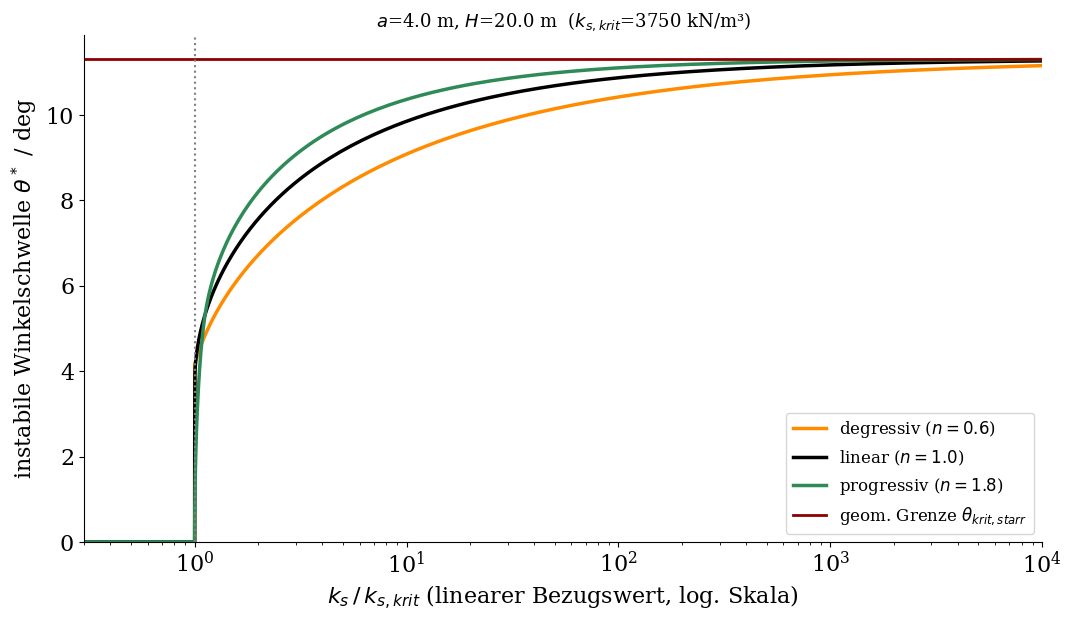

In [19]:
plot_kippschwelle_federsteifigkeit()

**Konsistenzprobe -- Grenzfall starrer Baugrund:** Für $k_\text{s}\to\infty$ muss das Federmodell in die starre Wackelstein-Bedingung $\theta^\ast \to \theta_{\text{krit,starr}}=\arctan(a/2z_\text{G0})$ übergehen -- und genau das tut es asymptotisch.

**Zusammenfassung Turmbeispiel:** Die geometrische Kippgrenze $\theta_{\text{krit,starr}}=\arctan(a/2z_\text{G0})$ ist die obere Schranke der instabilen Winkelschwelle. Bei endlicher Bettungssteifigkeit kann eine endliche Störung diese Potentialschwelle bereits bei kleinerem Winkel überwinden. Größe und Verlauf der Bettungssteifigkeit beeinflussen daher die lokale Stabilität der aufrechten Lage und die Höhe der endlichen Energiebarriere.

## 4. Einordnung in die Stabilitäts- und Bifurkationstheorie

Das Turmbeispiel ist eine **Analogie** zum allgemeinen Stabilitätsproblem aus [stability_bifurcation.ipynb](stability_bifurcation.ipynb) (nach Bigoni): Beide sind konservative Systeme, deren reduziertes Potential von einem Drehwinkel abhängt. Im Referenzbeispiel wirken jedoch eine konzentrierte Drehfeder und eine verformbare Axialfeder; hier werden die vertikale Translation über das Vertikalgleichgewicht eliminiert und eine verteilte, zugfreie Bettung verwendet. Die Analogie und die Unterschiede lassen sich so zuordnen:

| dort (Bigoni-Beispiel) | hier (Turm auf Bettung) |
|---|---|
| Drehwinkel $\vartheta$ | Neigung $\theta$ |
| lineare Drehfeder $k_\text{r}$ | verteilte, gegebenenfalls nichtlineare und zugfreie Bettungsreaktion |
| Kraft $F$ (Kontrollparameter, last- **oder** weggesteuert) | Vertikallinienlast $V$ aus Eigengewicht (fest -- Kontrollparameter ist stattdessen $k_\text{s}$) |
| destabilisierendes Moment $Fl\sin\vartheta$ | destabilisierendes Moment $Vz_\text{G0}\sin\theta$ |
| Stabilitätsgrenze $\tilde{F}_\text{cr}=\tfrac{1\pm\sqrt{1-4\tilde{k}}}{2}$ | Stabilitätsgrenze $k_\text{s,krit}=12Vz_\text{G0}/a^3$ |

Wir übertragen die dortige **energetische** Herangehensweise (totales Potential $\Pi$, erste Variation = Gleichgewicht, zweite Variation = Stabilität) direkt auf unseren Turm.

**Totales Potential:** Neben dem Winkel muss zunächst die vertikale Absenkung $s_0$ des Sohlflächenmittelpunkts berücksichtigt werden. Mit der Federenergiedichte $\Psi(s)=\int_0^s\sigma(u)\,\mathrm{d}u$ für $s>0$ und $\Psi=0$ für $s\leq0$ lautet das Potential je Längeneinheit des Streifenfundaments

$$
    \Pi(s_0,\theta)=\int_{-a/2}^{a/2}\Psi\!\left(s_0+x\sin\theta\right)\,\mathrm{d}x
    -V\left[s_0+z_\text{G0}(1-\cos\theta)\right].
$$

Die Stationarität bezüglich $s_0$ liefert das Vertikalgleichgewicht. Setzt man dessen Lösung $s_0(\theta)$ ein, erhält man das reduzierte Potential $\Pi_\text{red}(\theta)=\Pi(s_0(\theta),\theta)$. Nach dem Hüllkurvensatz gilt

$$
    \frac{\mathrm{d}\Pi_\text{red}}{\mathrm{d}\theta} = M_\text{found}(\theta) - Vz_\text{G0}\sin\theta = G(\theta) \overset{!}{=} 0, \qquad
    \frac{\mathrm{d}^2\Pi_\text{red}}{\mathrm{d}\theta^2} = \frac{\mathrm{d}G}{\mathrm{d}\theta}.
$$

Für die immer vorhandene triviale Lösung $\theta=0$ reproduziert die zweite Variation das frühere Kriterium. Für $k_\text{s}>k_{\text{s,krit}}$ ist $\theta=0$ ein Potentialminimum; das reduzierte Potential steigt bis zum nichttrivialen Gleichgewicht $\theta^\ast$ an. Dort gilt $G=0$ und $\mathrm{d}G/\mathrm{d}\theta<0$: $\theta^\ast$ ist ein Potentialmaximum und damit die endliche Energiebarriere. Für $k_\text{s}<k_{\text{s,krit}}$ ist bereits die aufrechte Lage ein Maximum. Rechnerisch kann die Differenz des reduzierten Potentials auch direkt aus $\Pi_\text{red}(\theta)-\Pi_\text{red}(0)=\int_0^\theta G(\theta')\,\mathrm{d}\theta'$ bestimmt werden.

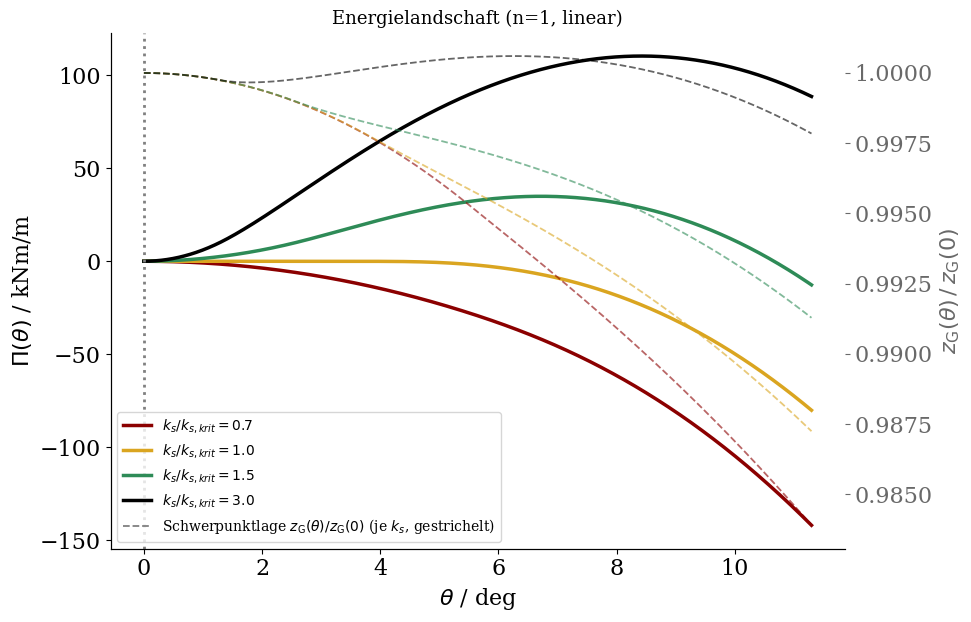

In [20]:
plot_energy_landscape()

Im Falle der elastischen Bettung ist es also nicht die Veränderung Schwerpunktlage allein, die die Stabilität bedingt.

**Momentenkarte:** Das Vorzeichen der zweiten Variation klassifiziert Stabilität nur an Gleichgewichtszuständen ($G=0$); für beliebige vorgegebene Winkel ist stattdessen das Vorzeichen des Momentenresiduums anschaulich. Die folgende Karte zeigt deshalb $G>0$ als rückstellenden und $G<0$ als kippenden Bereich. Die schwarze Kontur $G=0$ ist der nichttriviale Gleichgewichtspfad $\theta^\ast(k_\text{s})$. Sein negativer Anstieg in Winkelrichtung kennzeichnet ihn als instabil. Die lokale Stabilität des trivialen Pfades $\theta=0$ wechselt bei $k_\text{s}=k_{\text{s,krit}}$.

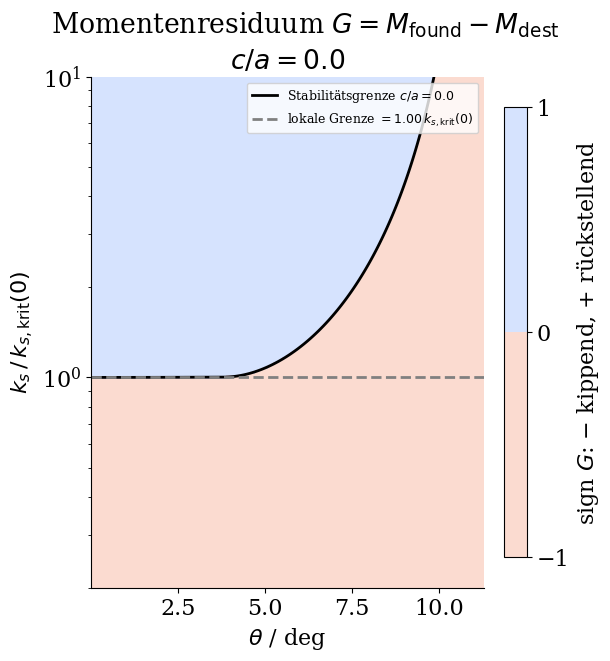

In [21]:
plot_stability_map()

Es ist also eine Mindeststeifigkeit der Bettung erforderlich, damit die aufrechte Lage lokal stabil ist. Oberhalb dieser Mindeststeifigkeit sind Störungen bis zur schwarzen Kurve rückstellend; im elastischen Modell kehrt die Wand in die Ausgangslage zurück. Wird bei festem $k_\mathrm{s}$ die schwarze Stabilitätsgrenze durch eine größere Neigung überschritten, ist das Momentenresiduum kippend.

## 5. Durchbrochenes Streifenfundament mit nichttragendem Kern

Geometrie und Masseverteilung des Wandstreifens bleiben unverändert. In der Sohlfläche wird nun jedoch eine symmetrische, nichttragende Mittelzone der Breite $c$ angenommen. Der Bodenkontakt besteht damit aus den beiden Randstreifen

$$
    x\in\left[-\frac a2,-\frac c2\right]\cup\left[\frac c2,\frac a2\right],
    \qquad 0\le c<a.
$$

Je Längeneinheit betragen die gesamte Kontaktbreite und ihr zweites Flächenmoment

$$
    A_\mathrm{c}=a-c,
    \qquad
    I_\mathrm{c}=\int_{A_\mathrm{c}}x^2\,\mathrm{d}x
    =\frac{a^3-c^3}{12}.
$$

Mit $r=c/a$ vergrößern sich die beiden symmetrischen Kernweiten. Die **1. Kernweite** bezeichnet die größte Exzentrizität, bis zu der beide Randstreifen vollständig unter Druck stehen. Wie beim vollflächigen Fundament ist die **2. Kernweite** erreicht, wenn die extrapolierte Nulldrucklinie durch den Sohlflächenmittelpunkt $x=0$ verläuft. Bei $c>0$ liegt diese Linie dann innerhalb des nichttragenden Kerns; der gegenüberliegende Randstreifen ist bereits vollständig entlastet:

$$
    \boxed{\frac{e_1}{a}=\frac{1+r+r^2}{6}},
    \qquad
    \boxed{\frac{e_2}{a}=\frac{1+r+r^2}{3(1+r)}}.
$$

Für $r=0$ folgen die bekannten Werte $e_1/a=1/6$ und $e_2/a=1/3$; für $r\to1$ nähern sich beide der unveränderten geometrischen Kippgrenze $a/2$. Die größeren Kernweiten bedeuten, dass die verbleibenden Randstreifen bezogen auf ihre Kontaktbreite günstiger angeordnet sind. Die absolute Rotationssteifigkeit nimmt dagegen ab:

$$
    k_\varphi(0,c)=k_\mathrm{s}I_\mathrm{c}
    =\frac{k_\mathrm{s}(a^3-c^3)}{12}.
$$

Aus $k_\varphi(0,c)>Vz_\mathrm{G0}$ ergibt sich deshalb

$$
    \boxed{k_{\mathrm{s,krit}}(c)
    =\frac{12Vz_\mathrm{G0}}{a^3-c^3}
    =\frac{k_{\mathrm{s,krit}}(0)}{1-(c/a)^3}}.
$$

Ein breiterer nichttragender Kern erhöht somit zwar die Kernweiten, verlangt für die lokale Stabilität der aufrechten Lage aber einen größeren Bettungsmodul. In den folgenden Momentenkarten wird $k_\mathrm{s}$ stets auf den kritischen Wert des vollflächigen Fundaments $k_{\mathrm{s,krit}}(0)$ bezogen. Die durchgezogene schwarze Kurve ist jeweils die Stabilitätsgrenze des dargestellten Fundaments; in den beiden durchbrochenen Fällen ist die Grenze für $c/a=0$ zusätzlich schwarz gestrichelt eingetragen. Die graue horizontale Linie kennzeichnet die jeweilige lokale Grenze $k_{\mathrm{s,krit}}(c)$. Dadurch werden sowohl der Verlust lokaler Stabilität bei kleiner Bettungssteifigkeit als auch die Veränderung der endlichen Winkelschwelle unmittelbar sichtbar.

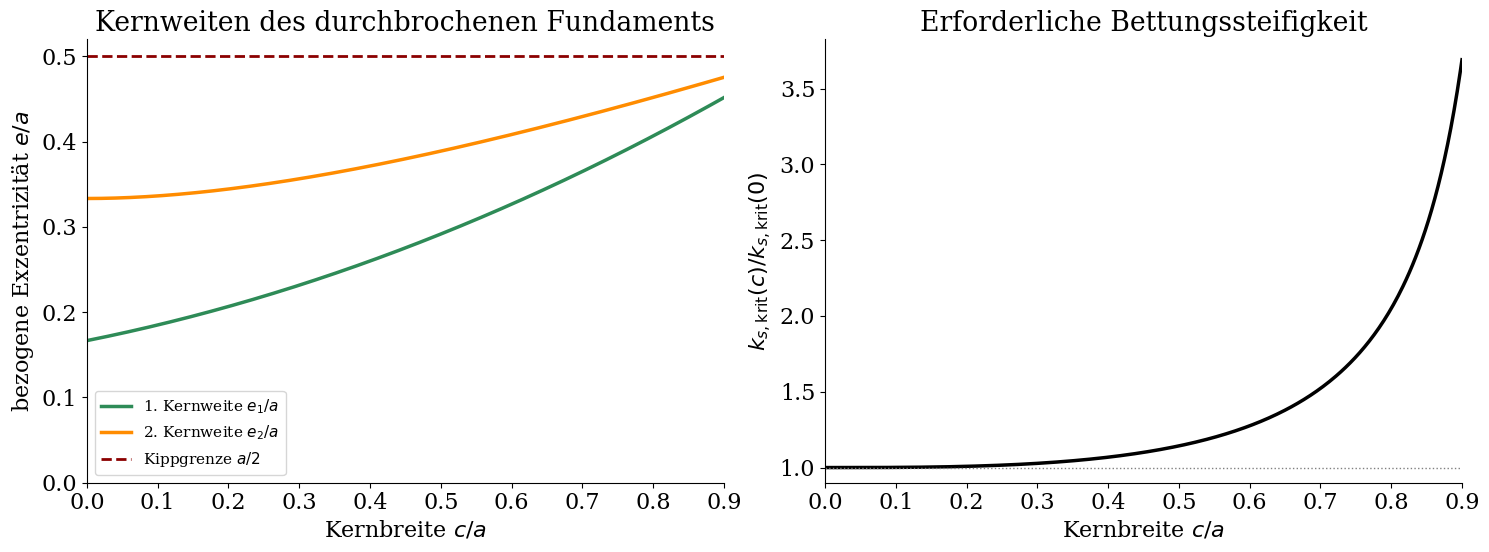

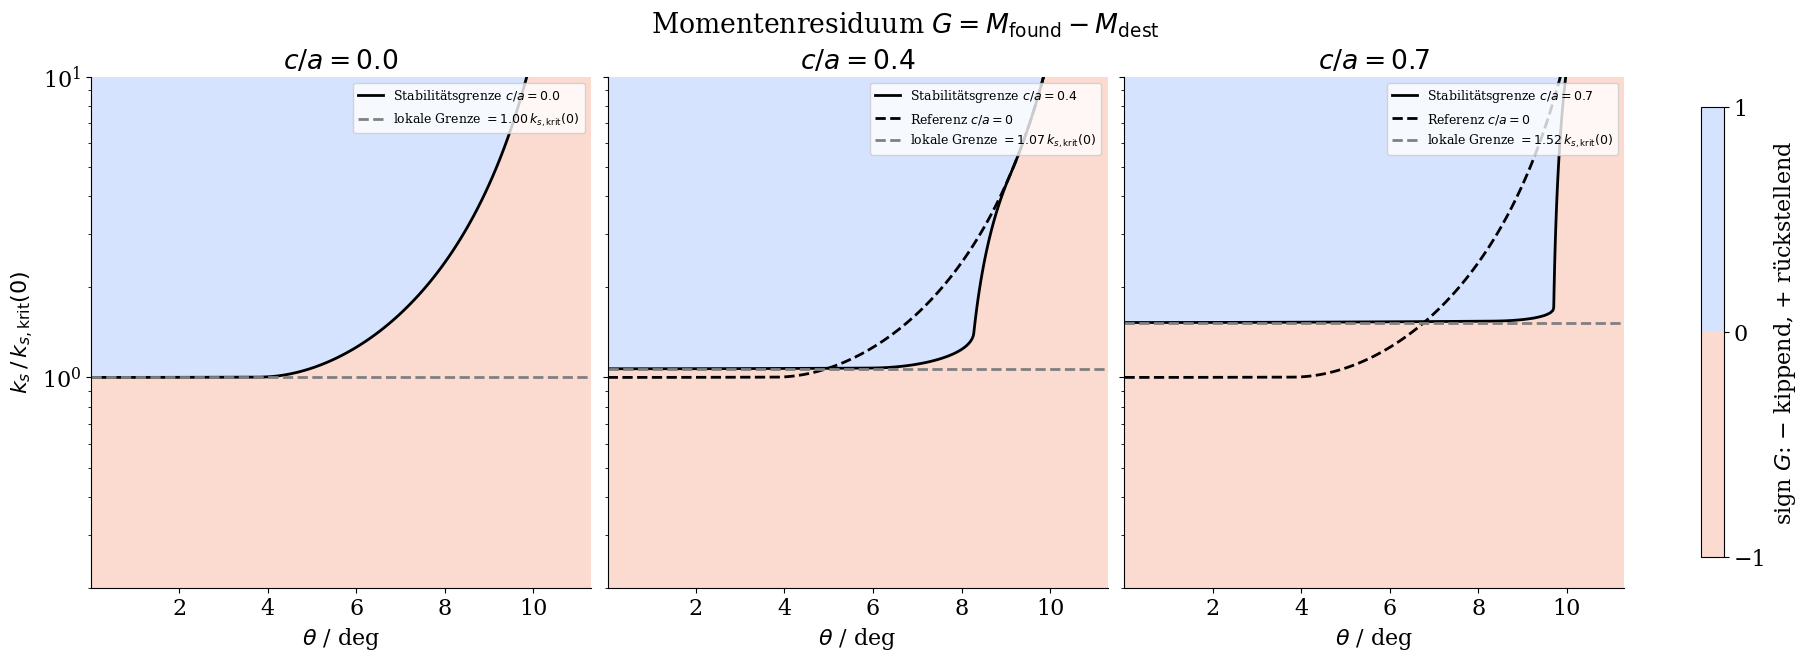

In [22]:
plot_hollow_foundation_characteristics()
plot_stability_map(c_ratios=(0.0, 0.4, 0.7))

Zwischen $k_{\mathrm{s,krit}}(0)$ und der höheren Grenze $k_{\mathrm{s,krit}}(c)$ verliert das durchbrochene Fundament die lokale Stabilität, obwohl das vollflächige Fundament bereits stabil ist. Oberhalb von $k_{\mathrm{s,krit}}(c)$ kann die endliche instabile Winkelschwelle bei gleichem Bettungsmodul dagegen gleich groß oder größer sein. Darin liegt kein Widerspruch zu den größeren Kernweiten: Diese beschreiben die Lage der Resultierenden in der verbleibenden Kontaktgeometrie, während die lokale Rotationssteifigkeit vom kleineren Flächenmoment $I_\mathrm{c}$ bestimmt wird.